# Задание 3. NLP
## Задача 1 5 баллов
- Напишите токенайзенр на основе BPE, используя претокенизацию и специальные токены. Можете использовать паттерны претокенизации открытых моделей, указав источник. 
- Обучите свой токенизатор на своем корпусе, токенизируйте тексты, не совпадающие с использованным для обучения. 
- Определите коэффициент сжатия (число токенов к количеству байт/символов), среднее количество токенов на слово, среднее количество токенов на слово для топ 10% частотных слов. Ответьте на вопрос, отличается ли эффективность для разных доменов?
- Постройте кривую: размер словаря vs compression ratio
- Определите, какая часть токенов не использовалась ни разу при токенизации [корпуса стихотворений Пушкина](https://dataverse.pushdom.ru/dataset.xhtml?persistentId=doi:10.31860/openlit-2023.8-C005)


In [86]:
import pandas as pd
import re
import os

from collections import Counter
import matplotlib.pyplot as plt

from tokenizers import Tokenizer
from tokenizers.models import BPE
from tokenizers.trainers import BpeTrainer
from tokenizers.pre_tokenizers import Whitespace
from tokenizers.pre_tokenizers import ByteLevel
from tokenizers.decoders import ByteLevel as ByteLevelDecoder

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from torch.amp import autocast, GradScaler

from transformers import GPT2LMHeadModel

from typing import List, Dict, Tuple, Set



In [34]:
#Anime corpuses
#https://www.kaggle.com/datasets/theodaimones888/russian-anime-reviews-dataset
#https://www.kaggle.com/datasets/assilsigma/findaminenet-russian-anime-dataset

#Maybe starting at 11:30 PM is a bad idea, i dont know)) It will be fun ;)

anime_reviews = pd.read_csv("/home/kalisto/Documents/spbu_dl_2025/data/ANIME/Anime_reviews_RU.csv")
anime_description = pd.read_csv("/home/kalisto/Documents/spbu_dl_2025/data/ANIME/extended_anime.csv")

anime_description = anime_description["Description"]
anime_reviews = anime_reviews["Text"]

anime_description = anime_description.str.cat()
anime_reviews = anime_reviews.str.cat()

In [35]:
print(anime_reviews[:500])
print(anime_description[:500])

после первой арки несколько разочаровался, ожидал большего. еще пять раз смотреть одно и то же с разными героинями как-то желания нет. отложу просмотр остальных серий на потом. :lonely:Концовка какая-то мутная, ничего не понял. Надеюсь на второй сезон.Само аниме сильно понравилось, побольше бы таких. Засилье школьных эччи удручает.Что тут сказать? Никакого сравнени я с Seed, хоть и пытается ему подражать... Банаджер вообще не выдерживает никакого сравнения с обаятельным, харизматичным, молчаливы
«Ходячий замок» — полнометражное аниме, выпущенное студией «Ghibli» в 2004 году. Создан японским режиссёром Хаяо Миядзаки по мотивам одноимённого сказочного романа английской писательницы Дианы Уинн Джонс. Действие фильма происходит в параллельном мире Европы конца XIX-го века, где магия идёт рука об руку с техническим прогрессом. Скромная жизнь шляпницы Софи полностью изменяется, когда в окрестностях её города появляется ходячий замок таинственного волшебника Хаула, известного своими «похищени

In [36]:
anime_reviews = re.sub(r'[^a-zA-Zа-яА-Я0-9\s.,!?;:\-—()"\'\[\]{}]', '', anime_reviews)
anime_description = re.sub(r'[^a-zA-Zа-яА-Я0-9\s.,!?;:\-—()"\'\[\]{}]', '', anime_description)

In [37]:
print(anime_reviews[:500])
print(anime_description[:500])

после первой арки несколько разочаровался, ожидал большего. еще пять раз смотреть одно и то же с разными героинями как-то желания нет. отложу просмотр остальных серий на потом. :lonely:Концовка какая-то мутная, ничего не понял. Надеюсь на второй сезон.Само аниме сильно понравилось, побольше бы таких. Засилье школьных эччи удручает.Что тут сказать? Никакого сравнени я с Seed, хоть и пытается ему подражать... Банаджер вообще не выдерживает никакого сравнения с обаятельным, харизматичным, молчаливы
Ходячий замок — полнометражное аниме, выпущенное студией Ghibli в 2004 году. Создан японским режиссром Хаяо Миядзаки по мотивам одноимнного сказочного романа английской писательницы Дианы Уинн Джонс. Действие фильма происходит в параллельном мире Европы конца XIX-го века, где магия идт рука об руку с техническим прогрессом. Скромная жизнь шляпницы Софи полностью изменяется, когда в окрестностях е города появляется ходячий замок таинственного волшебника Хаула, известного своими похищениями девич

In [38]:
print(len(anime_reviews))
print(len(anime_description))

95064384
3475123


In [39]:
anime_reviews = anime_reviews[:3475123]
anime_description = anime_description[:3475123]
print(len(anime_reviews))

3475123


##### Напишите токенайзенр на основе BPE, используя претокенизацию и специальные токены. Можете использовать паттерны претокенизации открытых моделей, указав источник. 

In [ ]:
class CustomBPE():
    def __init__(self, vocab_size: int):
        self.merges = {}
        self.special_tokens = {}
        self.vocab = self._build_vocab()
        self.vocab_size = vocab_size

    def _build_vocab(self):
        # дополнительный метод, который помогает построить словарь.
        # начальный словарь - содержит все возможные символы по одному
        vocab = {idx: bytes([idx]) for idx in range(256)} 
        # конкатенируем байты из наших мерджей
        for (p0, p1), idx in self.merges.items():
            vocab[idx] = vocab[p0] + vocab[p1]

        # не забываем про <bos>,<eos>, <|user|>, <think> и тд.
        for special, idx in self.special_tokens.items():
            vocab[idx] = special.encode("utf-8")
        return vocab

    def get_stats(self, ids: list[int]) -> dict[tuple[int, int], int]:
        """counts pairs in text. Note that consecutive pairs overlap (if you have abc, pairs are ab, bc)"""
        counts = {}
        for pair in zip(ids, ids[1:]):
            counts[pair] = counts.get(pair, 0) + 1
        return counts

    def merge(self, ids: list[int], pair: tuple[int, int], new_id: int) -> list[int]:
        """
        Merges all the occurencies of pair in list of ids int one new_id.
        """
        new_ids = []
        i = 0
        while i < len(ids):
            # check that ids[i] and [i+1] are both from pair and put the new id to list 
            if i < len(ids) - 1 and ids[i] == pair[0] and ids[i + 1] == pair[1]:
                new_ids.append(new_id)
                i += 2
            else:
                # else just add current id to it and go to the next token
                new_ids.append(ids[i])
                i += 1
        return new_ids

    def fit(self, dataset: list[int], verbose: bool = True) -> None:
        num_merges = self.vocab_size - 256 #256 (базовые байты)
        ids = list(dataset)
        first_merge_id = 256
        
        for i in range(num_merges):
            stats = self.get_stats(ids)
            
            # Если нет пар
            if not stats:
                break
            
            # Самая частая пара
            next_pair = max(stats, key=stats.get)
            new_id = first_merge_id + i
            self.merges[next_pair] = new_id
            
            ids = self.merge(ids, next_pair, new_id)
            
            if verbose:
                print(f"New merged pair is: {next_pair} -> {new_id}")
                
        self.vocab = self._build_vocab()

    def encode(self, text: str) -> list[tuple[int, bytes]]:
        """ 
        Get sequence of token ids using merge dict
        Returns list of tuples (token_id, byte_sequence)
        """
        # Конвертируем текст в байты, затем в список ID
        tokens = list(text.encode("utf-8"))
        
        # Применяем слияни
        while len(tokens) >= 2:
            stats = self.get_stats(tokens)
            
            # раньше всего добавленная пара
            pair = min(stats, key=lambda x: self.merges.get(x, float("inf")))
            
            # Если пара не в словаре слияний, заканчиваем
            if pair not in self.merges:
                break
            
            new_id = self.merges[pair]
            tokens = self.merge(tokens, pair, new_id)
            
        return [(token_id, self.vocab[token_id]) for token_id in tokens]

    def decode(self, token_ids) -> str:
        """  
        From list of ids or list of tuples (id, bytes) we get string.
        Can also accept single token_id or single tuple.
        """
        if not isinstance(token_ids, list):
            token_ids = [token_ids]
        
        if not token_ids:
            return ""
        
        if isinstance(token_ids[0], tuple):
            token_ids = [token_id for token_id, _ in token_ids]
        
        # Собираем байты из токенов
        tokens_bytes = b"".join(self.vocab[idx] for idx in token_ids)
        # Декодируем в строку
        text = tokens_bytes.decode("utf-8", errors="replace")
        return text

In [85]:
tokenizer_anime_reviews = CustomBPE(vocab_size=1000)  # 256 базовых байтов
corpus = anime_reviews
dataset = list(corpus.encode("utf-8"))
tokenizer_anime_reviews.fit(dataset, verbose=True)

New merged pair is: (32, 208) -> 256
New merged pair is: (208, 190) -> 257
New merged pair is: (208, 181) -> 258
New merged pair is: (208, 176) -> 259
New merged pair is: (209, 130) -> 260
New merged pair is: (208, 184) -> 261
New merged pair is: (209, 129) -> 262
New merged pair is: (208, 189) -> 263
New merged pair is: (209, 128) -> 264
New merged pair is: (257, 208) -> 265
New merged pair is: (259, 208) -> 266
New merged pair is: (208, 187) -> 267
New merged pair is: (209, 131) -> 268
New merged pair is: (209, 143) -> 269
New merged pair is: (209, 140) -> 270
New merged pair is: (258, 208) -> 271
New merged pair is: (256, 191) -> 272
New merged pair is: (32, 262) -> 273
New merged pair is: (256, 189) -> 274
New merged pair is: (209, 139) -> 275
New merged pair is: (209, 135) -> 276
New merged pair is: (261, 208) -> 277
New merged pair is: (256, 178) -> 278
New merged pair is: (260, 257) -> 279
New merged pair is: (256, 184) -> 280
New merged pair is: (208, 186) -> 281
New merged pai

In [87]:
encoded = tokenizer_anime_reviews.encode("Один воин вышел в лес")
for token_id, byte_seq in encoded:
    print(f"Token ID: {token_id:3d} | Bytes: {byte_seq} | Text: {byte_seq.decode('utf-8', errors='replace')}")
    
decoded = tokenizer_anime_reviews.decode(encoded)
print(f"Decoded: {decoded}")

Token ID: 567 | Bytes: b'\xd0\x9e' | Text: О
Token ID: 286 | Bytes: b'\xd0\xb4' | Text: д
Token ID: 332 | Bytes: b'\xd0\xb8\xd0\xbd' | Text: ин
Token ID: 543 | Bytes: b' \xd0\xb2\xd0\xbe' | Text:  во
Token ID: 332 | Bytes: b'\xd0\xb8\xd0\xbd' | Text: ин
Token ID: 422 | Bytes: b' \xd0\xb2\xd1\x8b' | Text:  вы
Token ID: 300 | Bytes: b'\xd1\x88' | Text: ш
Token ID: 313 | Bytes: b'\xd0\xb5\xd0\xbb' | Text: ел
Token ID: 278 | Bytes: b' \xd0\xb2' | Text:  в
Token ID: 355 | Bytes: b' \xd0\xbb' | Text:  л
Token ID: 350 | Bytes: b'\xd0\xb5\xd1\x81' | Text: ес
Decoded: Один воин вышел в лес


In [88]:
corpus = anime_reviews

tokenizer_anime_reviews = Tokenizer(BPE(unk_token="[UNK]"))

tokenizer_anime_reviews.pre_tokenizer = ByteLevel()
tokenizer_anime_reviews.decoder = ByteLevelDecoder()

#tokenizer_anime_reviews.pre_tokenizer = Whitespace()

trainer = BpeTrainer(
    vocab_size=5000,
    special_tokens=["[UNK]", "[PAD]", "[CLS]", "[SEP]", "[MASK]"],
    show_progress=False,
    initial_alphabet=[]
)

tokenizer_anime_reviews.train_from_iterator([corpus], trainer=trainer)

tokenizer_vocab_anime_reviews = tokenizer_anime_reviews.get_vocab()
print(f"Vocabulary size: {len(tokenizer_vocab_anime_reviews)}")
print(f"Sample tokens: {list(tokenizer_vocab_anime_reviews.keys())[:20]}")

#tokenizer_anime_reviews.save("anime_tokenizer.json")

sample_text = "Один воин вышел в лес"
encoding = tokenizer_anime_reviews.encode(sample_text)
print(f"\nOriginal: {sample_text}")
print(f"Tokens: {encoding.tokens}")
print(f"IDs: {encoding.ids}")

decoded = tokenizer_anime_reviews.decode(encoding.ids)
print(f"Decoded: {decoded}")

Vocabulary size: 5000
Sample tokens: ['ĠÐ¼Ð¾Ð½', 'ÐºÐ¸Ð¼Ð¸', 'ĠÑĨÐµÐ½Ð·', '....', 'ĠÐ½ÐµÑĤ', 'ĠÐ³Ð°ÑĢÐµÐ¼Ð½Ð¸Ðº', 'Ð°ÑİÑīÐ¸Ð¼', 'ĠÐ·Ð°Ð±ÑĭÐ»', 'ĠÑĤÑĢÐµÑĤ', 'ĠÑĢÐ°Ð·Ð²Ð¸ÑĤ', 'Ð¼Ð°ÑĤ', 'Ð¿ÑĢÐ¾ÑĩÐµÐ¼', ').', 'ĠÐ²ÐµÑĩ', 'Ð¸Ð²Ð°Ñİ', 'ÐĵÑĢÐ°ÑĦÐ¸ÐºÐ°', 'ĠÐ´ÑĥÑĪÑĥ', 'Ð»ÑıÐ´', 'ÑĤÐ¾Ñĩ', 'ĠÐ¿Ð¾ÑĢÐ°Ð´Ð¾Ð²Ð°Ð»Ð°']

Original: Один воин вышел в лес
Tokens: ['ĠÐŀ', 'Ð´Ð¸Ð½', 'ĠÐ²Ð¾', 'Ð¸Ð½', 'ĠÐ²ÑĭÑĪÐµÐ»', 'ĠÐ²', 'ĠÐ»ÐµÑģ']
IDs: [356, 887, 437, 225, 3848, 171, 4918]
Decoded:  Один воин вышел в лес


In [89]:
corpus = anime_description

tokenizer_anime_description = Tokenizer(BPE(unk_token="[UNK]"))

tokenizer_anime_description.pre_tokenizer = ByteLevel()
tokenizer_anime_description.decoder = ByteLevelDecoder()

#tokenizer_anime_description.pre_tokenizer = Whitespace()

trainer = BpeTrainer(
    vocab_size=5000,
    special_tokens=["[UNK]", "[PAD]", "[CLS]", "[SEP]", "[MASK]"],
    show_progress=False,
    initial_alphabet=[]
    
)

tokenizer_anime_description.train_from_iterator([corpus], trainer=trainer)

tokenizer_vocab_anime_description = tokenizer_anime_description.get_vocab()
print(f"Vocabulary size: {len(tokenizer_vocab_anime_description)}")
print(f"Sample tokens: {list(tokenizer_vocab_anime_description.keys())[:20]}")

#tokenizer_anime_description.save("anime_tokenizer.json")

sample_text = "Один воин вышел в лес"
encoding = tokenizer_anime_description.encode(sample_text)
print(f"\nOriginal: {sample_text}")
print(f"Tokens: {encoding.tokens}")
print(f"IDs: {encoding.ids}")

decoded = tokenizer_anime_description.decode(encoding.ids)
print(f"Decoded: {decoded}")

Vocabulary size: 5000
Sample tokens: ['ĠÐ½Ð°Ð´ÐµÐ¶Ð´Ñĭ', 'ÑıÐ»', 'ĠÐ¿ÐµÑĢÐµÐµÑħ', 'ĠÐºÑĢÐ°ÑģÐ°Ð²', 'Ð½Ð¸ÐºÐ°', 'ĠÐ±Ð»Ð°Ð³Ð¾Ð´Ð°ÑĢÑı', 'ĠFindAnimeÐĴ', 'ĠÐ½Ð°Ð¿', 'ÐµÐ´', 'Ðĵ', 'ÑģÑĥÐ´', 'Ð»ÐµÑĤÐ½Ð¸Ð¹', 'Ð»ÐµÐ½Ð¸Ð¹', 'ÐµÑĢÑĥ', 'ĠÐ½Ð°Ð¿Ð°ÑĢ', 'Ð¸ÑĩÐ½ÑĭÐ¹', 'ĠÐ¾ÑģÐ²', 'ÑĥÐ»', 'ac', 'ĠÐ²Ð»ÑİÐ±']

Original: Один воин вышел в лес
Tokens: ['ĠÐŀÐ´Ð¸Ð½', 'ĠÐ²Ð¾Ð¸Ð½', 'ĠÐ²ÑĭÑĪ', 'ÐµÐ»', 'ĠÐ²', 'ĠÐ»ÐµÑģ']
IDs: [4017, 4110, 2595, 200, 166, 2193]
Decoded:  Один воин вышел в лес


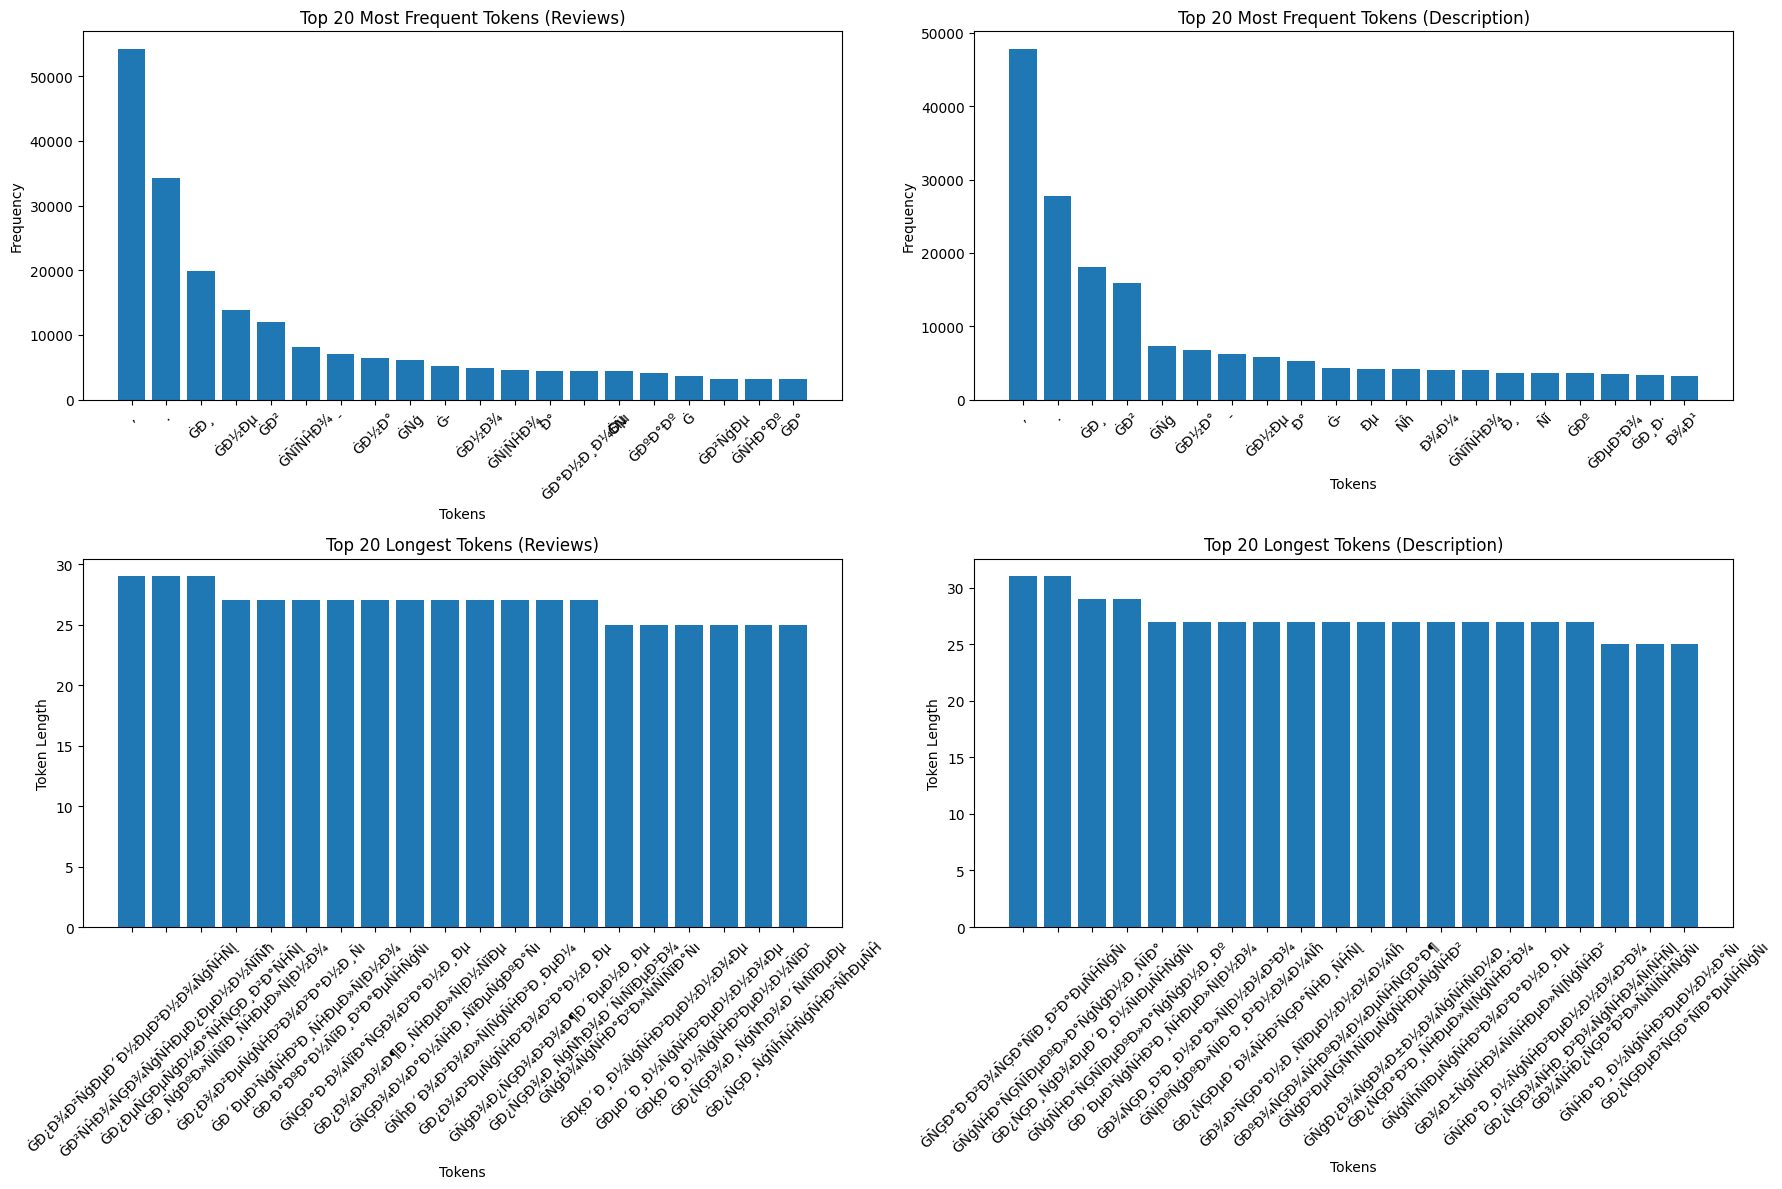

In [90]:
all_tokens_reviews = []
for text in anime_reviews.split('\n'):
    encoded = tokenizer_anime_reviews.encode(text)
    all_tokens_reviews.extend(encoded.tokens)

all_tokens_description = []
for text in anime_description.split('\n'):
    encoded = tokenizer_anime_description.encode(text)
    all_tokens_description.extend(encoded.tokens)

token_counts_reviews = Counter(all_tokens_reviews)
token_counts_description = Counter(all_tokens_description)

most_common_reviews = token_counts_reviews.most_common(20)
most_common_description = token_counts_description.most_common(20)

tokens_reviews, counts_reviews = zip(*most_common_reviews)
tokens_description, counts_description = zip(*most_common_description)

unique_tokens_reviews = list(set(all_tokens_reviews))
unique_tokens_reviews.sort(key=len, reverse=True)
longest_tokens_reviews = unique_tokens_reviews[:20]
lengths_longest_reviews = [len(t) for t in longest_tokens_reviews]

unique_tokens_description = list(set(all_tokens_description))
unique_tokens_description.sort(key=len, reverse=True)
longest_tokens_description = unique_tokens_description[:20]
lengths_longest_description = [len(t) for t in longest_tokens_description]

fig, axs = plt.subplots(2, 2, figsize=(18,12))

axs[0,0].bar(tokens_reviews, counts_reviews)
axs[0,0].set_xticks(range(len(tokens_reviews)))
axs[0,0].set_xticklabels(tokens_reviews, rotation=45)
axs[0,0].set_xlabel("Tokens")
axs[0,0].set_ylabel("Frequency")
axs[0,0].set_title("Top 20 Most Frequent Tokens (Reviews)")

axs[0,1].bar(tokens_description, counts_description)
axs[0,1].set_xticks(range(len(tokens_description)))
axs[0,1].set_xticklabels(tokens_description, rotation=45)
axs[0,1].set_xlabel("Tokens")
axs[0,1].set_ylabel("Frequency")
axs[0,1].set_title("Top 20 Most Frequent Tokens (Description)")

axs[1,0].bar(longest_tokens_reviews, lengths_longest_reviews)
axs[1,0].set_xticks(range(len(longest_tokens_reviews)))
axs[1,0].set_xticklabels(longest_tokens_reviews, rotation=45)
axs[1,0].set_xlabel("Tokens")
axs[1,0].set_ylabel("Token Length")
axs[1,0].set_title("Top 20 Longest Tokens (Reviews)")

axs[1,1].bar(longest_tokens_description, lengths_longest_description)
axs[1,1].set_xticks(range(len(longest_tokens_description)))
axs[1,1].set_xticklabels(longest_tokens_description, rotation=45)
axs[1,1].set_xlabel("Tokens")
axs[1,1].set_ylabel("Token Length")
axs[1,1].set_title("Top 20 Longest Tokens (Description)")


plt.tight_layout()
plt.show()

In [91]:
encoding = tokenizer_anime_description.encode(anime_reviews[:50])
print(f"\nOriginal: {anime_reviews[:50]}")
print(f"Tokens: {encoding.tokens}")
print(f"IDs: {encoding.ids}")

encoding = tokenizer_anime_reviews.encode(anime_description[:50])
print(f"\nOriginal: {anime_description[:50]}")
print(f"Tokens: {encoding.tokens}")
print(f"IDs: {encoding.ids}")


Original: после первой арки несколько разочаровался, ожидал 
Tokens: ['ĠÐ¿Ð¾ÑģÐ»Ðµ', 'ĠÐ¿ÐµÑĢÐ²Ð¾Ð¹', 'ĠÐ°ÑĢ', 'ÐºÐ¸', 'ĠÐ½ÐµÑģÐºÐ¾Ð»ÑĮÐºÐ¾', 'ĠÑĢÐ°Ð·', 'Ð¾Ñĩ', 'Ð°ÑĢÐ¾Ð²', 'Ð°Ð»ÑģÑı', ',', 'ĠÐ¾Ð¶Ð¸Ð´', 'Ð°Ð»', 'Ġ']
IDs: [634, 2410, 896, 355, 1699, 335, 308, 1895, 872, 10, 2612, 204, 112]

Original: Ходячий замок — полнометражное аниме, выпущенное с
Tokens: ['ĠÐ¥', 'Ð¾Ð´', 'ÑıÑĩ', 'Ð¸Ð¹', 'ĠÐ·Ð°Ð¼', 'Ð¾Ðº', 'ĠâĢĶ', 'ĠÐ¿Ð¾Ð»Ð½Ð¾Ð¼ÐµÑĤÑĢÐ°Ð¶', 'Ð½Ð¾Ðµ', 'ĠÐ°Ð½Ð¸Ð¼Ðµ', ',', 'ĠÐ²ÑĭÐ¿', 'ÑĥÑī', 'ÐµÐ½Ð½Ð¾Ðµ', 'ĠÑģ']
IDs: [498, 228, 3271, 287, 763, 300, 3148, 2662, 337, 283, 10, 1501, 824, 2178, 166]


##### Определите коэффициент сжатия (число токенов к количеству байт/символов), среднее количество токенов на слово, среднее количество токенов на слово для топ 10% частотных слов. Ответьте на вопрос, отличается ли эффективность для разных доменов?

Compression Ratio = число символов/число токенов
	​


In [92]:
from collections import Counter

def text_stats(text, tokenizer):
    encoding = tokenizer.encode(text)
    num_tokens = len(encoding.ids)
    words = text.split()
    num_words = len(words)
    compression_ratio = num_tokens / len(text)
    avg_tokens_per_word = num_tokens / num_words
    word_counts = Counter(words)
    top_words = set(w for w, _ in word_counts.most_common(max(1, int(len(word_counts) * 0.1))))
    avg_tokens_top10 = sum(len(tokenizer.encode(w).ids) for w in words if w in top_words) / max(1, sum(1 for w in words if w in top_words))
    print(f"Compression ratio: {compression_ratio}")
    print(f"Average tokens per word: {avg_tokens_per_word}")
    print(f"Average tokens per top 10% frequent words: {avg_tokens_top10}")

print(f"Anime_reviews with anime_reviews tokenizer")
text_stats(anime_reviews, tokenizer_anime_reviews)

print(f"\nAnime_description with anime_description tokenizer")
text_stats(anime_description, tokenizer_anime_description)


print(f"\n\nAnime_reviews with anime_description tokenizer")
text_stats(anime_reviews, tokenizer_anime_description)

print(f"\nAnime_description with anime_reviews tokenizer")
text_stats(anime_description, tokenizer_anime_reviews)


Anime_reviews with anime_reviews tokenizer
Compression ratio: 0.2821405170406918
Average tokens per word: 1.8610733592492483
Average tokens per top 10% frequent words: 1.3088429028280517

Anime_description with anime_description tokenizer
Compression ratio: 0.28992815506098635
Average tokens per word: 2.0310195656293213
Average tokens per top 10% frequent words: 1.4205187493431126


Anime_reviews with anime_description tokenizer
Compression ratio: 0.32411773626429913
Average tokens per word: 2.1379661827679413
Average tokens per top 10% frequent words: 1.5809055025318246

Anime_description with anime_reviews tokenizer
Compression ratio: 0.3296303468970739
Average tokens per word: 2.3091433939291317
Average tokens per top 10% frequent words: 1.674695133209673


##### Ответьте на вопрос, отличается ли эффективность для разных доменов?
- Судя по полученным результатам, лучше всего токенизировать на собственном трейне, что логично.
- Использование токенизатора обученного на обзорах показало лучший результат при токенизации, по сравнению с токенизатором обученном на описаниях.

##### Постройте кривую: размер словаря vs compression ratio

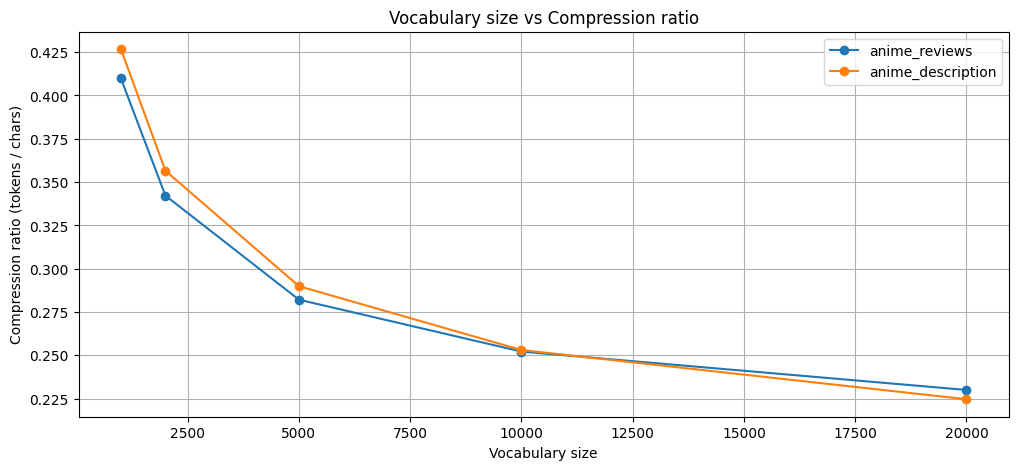

In [93]:
corpora = {
    "anime_reviews": anime_reviews,
    "anime_description": anime_description
}

vocab_sizes = [1000, 2000, 5000, 10000, 20000]

plt.figure(figsize=(12,5))

for name, corpus in corpora.items():
    compression_ratios = []
    for vocab_size in vocab_sizes:
        tokenizer = Tokenizer(BPE(unk_token="[UNK]"))
        tokenizer.pre_tokenizer = ByteLevel()
        tokenizer.decoder = ByteLevelDecoder()
        trainer = BpeTrainer(
            vocab_size=vocab_size,
            special_tokens=["[UNK]", "[PAD]", "[CLS]", "[SEP]", "[MASK]"],
            show_progress=False
        )
        tokenizer.train_from_iterator([corpus], trainer=trainer)
        encoding = tokenizer.encode(corpus)
        compression_ratio = len(encoding.ids) / len(corpus.replace("\n", ""))
        compression_ratios.append(compression_ratio)
    plt.plot(vocab_sizes, compression_ratios, marker='o', label=name)

plt.xlabel("Vocabulary size")
plt.ylabel("Compression ratio (tokens / chars)")
plt.title("Vocabulary size vs Compression ratio")
plt.grid(True)
plt.legend()
plt.show()

##### Определите, какая часть токенов не использовалась ни разу при токенизации [корпуса стихотворений Пушкина]

In [94]:
folder = "/home/kalisto/Documents/spbu_dl_2025/data/Pushkin/texts"
all_texts = []

for filename in os.listdir(folder):
    if filename.endswith(".txt"):
        with open(os.path.join(folder, filename), "r", encoding="utf-8") as f:
            all_texts.append(f.read())

pushkin_poems = " ".join(all_texts)

Training tokenizers and calculating compression ratios...

Analyzing unused tokens on test corpus...
anime_reviews - Vocab 1000: 0.1020 unused
anime_reviews - Vocab 2000: 0.1555 unused
anime_reviews - Vocab 5000: 0.2862 unused
anime_reviews - Vocab 10000: 0.4222 unused
anime_reviews - Vocab 20000: 0.5583 unused
anime_description - Vocab 1000: 0.0750 unused
anime_description - Vocab 2000: 0.1120 unused
anime_description - Vocab 5000: 0.2610 unused
anime_description - Vocab 10000: 0.3986 unused
anime_description - Vocab 20000: 0.5483 unused


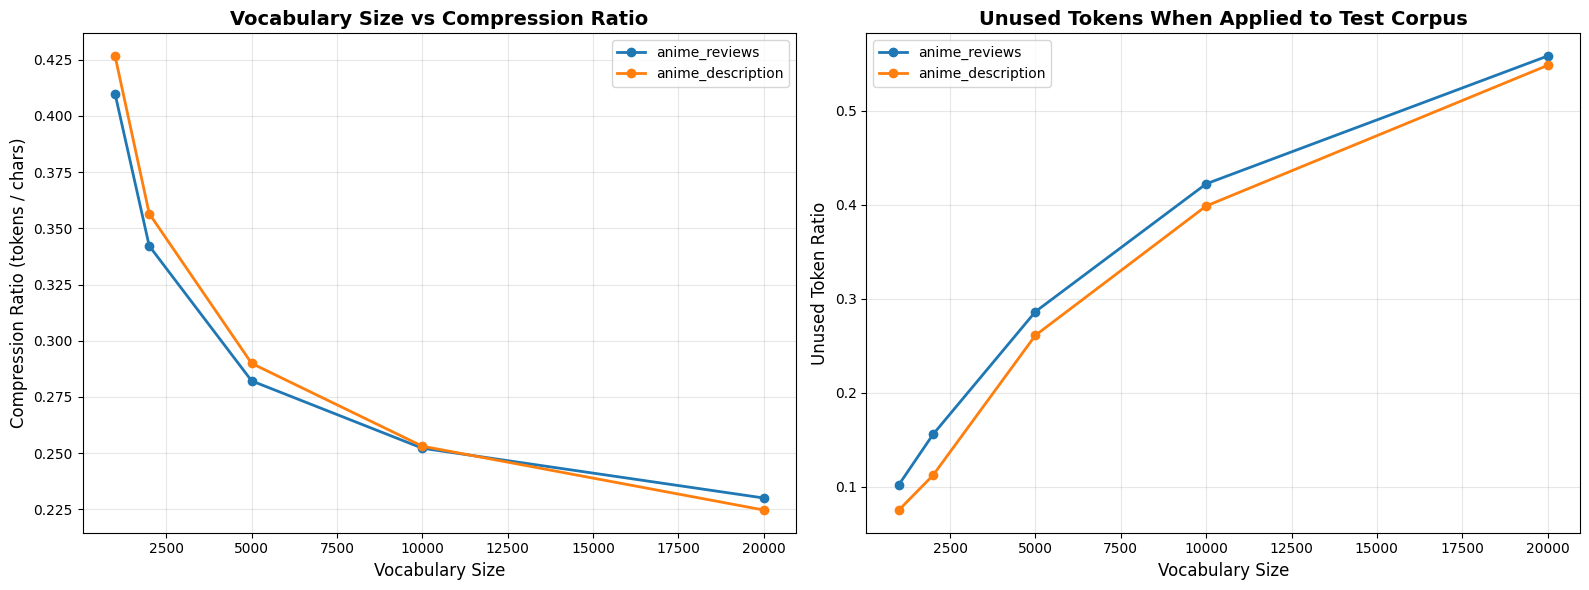

In [95]:
corpora = {
    "anime_reviews": anime_reviews,
    "anime_description": anime_description
}

vocab_sizes = [1000, 2000, 5000, 10000, 20000]

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))
tokenizers = {}

print("Training tokenizers and calculating compression ratios...")
for name, corpus in corpora.items():
    compression_ratios = []
    for vocab_size in vocab_sizes:
        tokenizer = Tokenizer(BPE(unk_token="[UNK]"))
        tokenizer.pre_tokenizer = ByteLevel()
        tokenizer.decoder = ByteLevelDecoder()
        trainer = BpeTrainer(
            vocab_size=vocab_size,
            special_tokens=["[UNK]", "[PAD]", "[CLS]", "[SEP]", "[MASK]"],
            show_progress=False
        )
        tokenizer.train_from_iterator([corpus], trainer=trainer)
        encoding = tokenizer.encode(corpus)
        compression_ratio = len(encoding.ids) / len(corpus.replace("\n", ""))
        compression_ratios.append(compression_ratio)
    
    ax1.plot(vocab_sizes, compression_ratios, marker='o', label=name, linewidth=2)

ax1.set_xlabel("Vocabulary Size", fontsize=12)
ax1.set_ylabel("Compression Ratio (tokens / chars)", fontsize=12)
ax1.set_title("Vocabulary Size vs Compression Ratio", fontsize=14, fontweight='bold')
ax1.grid(True, alpha=0.3)
ax1.legend(fontsize=10)

print("\nAnalyzing unused tokens on test corpus...")
test_corpus = pushkin_poems

for name, corpus in corpora.items():
    unused_ratios = []
    
    for vocab_size in vocab_sizes:
        tokenizer = Tokenizer(BPE(unk_token="[UNK]"))
        tokenizer.pre_tokenizer = ByteLevel()
        tokenizer.decoder = ByteLevelDecoder()
        trainer = BpeTrainer(
            vocab_size=vocab_size,
            special_tokens=["[UNK]", "[PAD]", "[CLS]", "[SEP]", "[MASK]"],
            show_progress=False
        )
        tokenizer.train_from_iterator([corpus], trainer=trainer)
        
        encoding = tokenizer.encode(test_corpus)
        vocab = tokenizer.get_vocab()
        used_token_ids = set(encoding.ids)
        unused_tokens = [token for token, idx in vocab.items() if idx not in used_token_ids]
        unused_ratio = len(unused_tokens) / len(vocab)
        unused_ratios.append(unused_ratio)
        
        print(f"{name} - Vocab {vocab_size}: {unused_ratio:.4f} unused")
    
    ax2.plot(vocab_sizes, unused_ratios, marker='o', label=name, linewidth=2)

ax2.set_xlabel("Vocabulary Size", fontsize=12)
ax2.set_ylabel("Unused Token Ratio", fontsize=12)
ax2.set_title("Unused Tokens When Applied to Test Corpus", fontsize=14, fontweight='bold')
ax2.grid(True, alpha=0.3)
ax2.legend(fontsize=10)

plt.tight_layout()
plt.show()

## Задача 1.1. 3 балла 
- Обучите простую модель (можно RNN/n-gram/transformer) с вашим токенизатором.

In [104]:
os.environ["TOKENIZERS_PARALLELISM"] = "false"

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

class TextDataset(Dataset):
    def __init__(self, encodings, seq_len=64):
        self.data = torch.tensor(encodings.ids, dtype=torch.long)
        self.seq_len = seq_len
        
    def __len__(self):
        return len(self.data) - self.seq_len
    
    def __getitem__(self, idx):
        x = self.data[idx:idx+self.seq_len]
        y = self.data[idx+1:idx+self.seq_len+1]
        return x, y

class GRU_RNN(nn.Module):
    def __init__(self, vocab_size, embed_dim=32, hidden_dim=64):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, embed_dim)
        self.rnn = nn.GRU(embed_dim, hidden_dim, num_layers=3, batch_first=True, dropout=0.2)
        self.fc = nn.Linear(hidden_dim, vocab_size)
        self.dropout = nn.Dropout(0.2)
        
    def forward(self, x):
        x = self.embedding(x)
        x = self.dropout(x)
        x, _ = self.rnn(x)
        x = self.dropout(x)
        x = self.fc(x)
        return x

test_corpus = anime_description
encoding = tokenizer_anime_reviews.encode(test_corpus)
vocab = tokenizer_anime_reviews.get_vocab()

vocab_size = len(vocab)
model = GRU_RNN(vocab_size).to(device)
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.01) 

dataset = TextDataset(encoding)
dataloader = DataLoader(dataset, batch_size=2048, shuffle=True, num_workers=2, pin_memory=True)

model.train()
for epoch in range(12):
    total_loss = 0
    for x, y in dataloader:
        x, y = x.to(device), y.to(device)
        optimizer.zero_grad()
        output = model(x)
        loss = criterion(output.reshape(-1, vocab_size), y.reshape(-1))
        loss.backward()
        
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        
        optimizer.step()
        total_loss += loss.item()
    print(f"Epoch {epoch+1}, Loss: {total_loss/len(dataloader):.4f}")

def generate(model, tokenizer, prompt, max_len=100, temperature=1.0):
    model.eval()
    tokens = tokenizer.encode(prompt).ids
    
    for _ in range(max_len):
        x = torch.tensor([tokens[-16:]]).to(device)
        with torch.no_grad():
            output = model(x)
        
        logits = output[0, -1] / temperature
        probs = torch.softmax(logits, dim=-1)
        next_token = torch.multinomial(probs, 1).item()
        
        tokens.append(next_token)
        
    return tokenizer.decode(tokens)

Epoch 1, Loss: 6.3632
Epoch 2, Loss: 5.2836
Epoch 3, Loss: 4.9843
Epoch 4, Loss: 4.8668
Epoch 5, Loss: 4.7947
Epoch 6, Loss: 4.7492
Epoch 7, Loss: 4.7230
Epoch 8, Loss: 4.7019
Epoch 9, Loss: 4.6894
Epoch 10, Loss: 4.6761
Epoch 11, Loss: 4.6682
Epoch 12, Loss: 4.6612


In [105]:
print(generate(model, tokenizer_anime_reviews, "Это аниме", 30))

 Это аниме. Танмо прилон предметы, может ничего обличя жизнь: и она не поверили в одиночеству. Это герой аним


In [106]:
print(generate(model, tokenizer_anime_reviews, "Anime", 30))

 AnimeКан большой нам единственный главный класс, а на сей сте достиг капину Цзусэ пути Империи ТавииОг


In [108]:
print(generate(model, tokenizer_anime_reviews, "Пушкин великий человек - ", 30))

 Пушкин великий человек -  обычная ошибка (..Чтобы выразить контролевные игрока и девушки своих дятушывают предсказывали в таком мире,


In [109]:
torch.cuda.empty_cache()

## Задача 1.2. 2 балла 
- Замените токенизатор GPT-2 на ваш (обученный на текстах, содержащих русский язык) и дообучите уже предобученный GPT-2 124M на нем.

In [110]:

os.environ["TOKENIZERS_PARALLELISM"] = "false"
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

class GPT2Dataset(Dataset):
    def __init__(self, encodings, seq_len=256):
        self.data = torch.tensor(encodings.ids, dtype=torch.long)
        self.seq_len = seq_len
        
    def __len__(self):
        return max(0, len(self.data) - self.seq_len)
    
    def __getitem__(self, idx):
        chunk = self.data[idx:idx + self.seq_len + 1]
        x = chunk[:-1]
        y = chunk[1:]
        
        if len(x) < self.seq_len:
            pad_len = self.seq_len - len(x)
            x = torch.cat([x, torch.zeros(pad_len, dtype=torch.long)])
            y = torch.cat([y, torch.zeros(pad_len, dtype=torch.long)])
        
        return x, y

def adapt_gpt2_to_new_tokenizer(model, new_vocab_size, old_vocab_size=50257):
    old_embeddings = model.transformer.wte.weight.data
    old_lm_head = model.lm_head.weight.data
    
    new_embeddings = nn.Embedding(new_vocab_size, model.config.n_embd)
    new_lm_head = nn.Linear(model.config.n_embd, new_vocab_size, bias=False)
    
    min_vocab = min(old_vocab_size, new_vocab_size)
    new_embeddings.weight.data[:min_vocab] = old_embeddings[:min_vocab]
    new_lm_head.weight.data[:min_vocab] = old_lm_head[:min_vocab]
    
    if new_vocab_size > old_vocab_size:
        nn.init.normal_(new_embeddings.weight.data[old_vocab_size:], std=0.02)
        nn.init.normal_(new_lm_head.weight.data[old_vocab_size:], std=0.02)
    
    model.transformer.wte = new_embeddings
    model.lm_head = new_lm_head
    model.config.vocab_size = new_vocab_size
    
    return model

def train_gpt2(model, dataloader, epochs=3, lr=5e-5):
    model.train()
    optimizer = torch.optim.AdamW(model.parameters(), lr=lr, weight_decay=0.01)
    scaler = GradScaler()
    
    for epoch in range(epochs):
        total_loss = 0
        for batch_idx, (x, y) in enumerate(dataloader):
            x, y = x.to(device), y.to(device)
            
            optimizer.zero_grad()
            
            with autocast(device_type="cuda"):
                outputs = model(input_ids=x, labels=y)
                loss = outputs.loss
            
            scaler.scale(loss).backward()
            scaler.unscale_(optimizer)
            torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            scaler.step(optimizer)
            scaler.update()
            
            total_loss += loss.item()
            
            if batch_idx % 10 == 0:
                print(f"Epoch {epoch+1}/{epochs}, Batch {batch_idx}, Loss: {loss.item():.4f}")
        
        print(f"Epoch {epoch+1}, Average Loss: {total_loss/len(dataloader):.4f}\n")

def generate_text(model, tokenizer, prompt, max_length=100, temperature=0.8):
    model.eval()
    tokens = tokenizer.encode(prompt).ids
    input_ids = torch.tensor([tokens]).to(device)
    
    sep_token_id = tokenizer.token_to_id("[SEP]")
    
    with torch.no_grad():
        for _ in range(max_length):
            outputs = model(input_ids)
            logits = outputs.logits[:, -1, :] / temperature
            probs = torch.softmax(logits, dim=-1)
            next_token = torch.multinomial(probs, 1)
            input_ids = torch.cat([input_ids, next_token], dim=-1)
            
            if sep_token_id and next_token.item() == sep_token_id:
                break
    
    return tokenizer.decode(input_ids[0].cpu().tolist())

In [112]:
test_corpus = anime_reviews[:100000]
encoding = tokenizer_anime_reviews.encode(test_corpus)
vocab = tokenizer_anime_reviews.get_vocab()

vocab_size = len(vocab)
model = GPT2LMHeadModel.from_pretrained('gpt2')
model = adapt_gpt2_to_new_tokenizer(model, vocab_size)
model = model.to(device)

dataset = GPT2Dataset(encoding, seq_len=64)
dataloader = DataLoader(dataset, batch_size=128, shuffle=True, 
                       num_workers=0, pin_memory=False)

train_gpt2(model, dataloader, epochs=3, lr=5e-5)

prompt = "Это аниме про"
generated = generate_text(model, tokenizer_anime_reviews, prompt, max_length=100)
print(f"\n{generated}")

Epoch 1/3, Batch 0, Loss: 10.6472
Epoch 1/3, Batch 10, Loss: 8.0852
Epoch 1/3, Batch 20, Loss: 7.4862
Epoch 1/3, Batch 30, Loss: 7.3110
Epoch 1/3, Batch 40, Loss: 7.1896
Epoch 1/3, Batch 50, Loss: 7.1452
Epoch 1/3, Batch 60, Loss: 7.1135
Epoch 1/3, Batch 70, Loss: 7.0922
Epoch 1/3, Batch 80, Loss: 7.1035
Epoch 1/3, Batch 90, Loss: 7.0418
Epoch 1/3, Batch 100, Loss: 7.0947
Epoch 1/3, Batch 110, Loss: 6.9955
Epoch 1/3, Batch 120, Loss: 7.0244
Epoch 1/3, Batch 130, Loss: 6.9681
Epoch 1/3, Batch 140, Loss: 6.9315
Epoch 1/3, Batch 150, Loss: 6.8648
Epoch 1/3, Batch 160, Loss: 6.8055
Epoch 1/3, Batch 170, Loss: 6.7117
Epoch 1/3, Batch 180, Loss: 6.6000
Epoch 1/3, Batch 190, Loss: 6.4946
Epoch 1/3, Batch 200, Loss: 6.3839
Epoch 1/3, Batch 210, Loss: 6.2434
Epoch 1/3, Batch 220, Loss: 6.1067
Epoch 1, Average Loss: 7.0515

Epoch 2/3, Batch 0, Loss: 6.0547
Epoch 2/3, Batch 10, Loss: 5.8745
Epoch 2/3, Batch 20, Loss: 5.8037
Epoch 2/3, Batch 30, Loss: 5.6373
Epoch 2/3, Batch 40, Loss: 5.3775
Epoch

In [113]:
prompt = "Аниме"
generated = generate_text(model, tokenizer_anime_reviews, prompt, max_length=50)
print(f"\n{generated}")


 Аниме ха, хмаЧ. высюжетат не но накика что похож атмосфера, главные не3. потом si.anarad.руительнаяка, выалсяic1:3 этот. этот Ium Aa..


In [ ]:
torch.cuda.empty_cache()

: 